In [1]:
from pathlib import Path

import gymnasium as gym
import ale_py
import imageio
import matplotlib.pyplot as plt
import numpy as np

import os; os.environ["LD_LIBRARY_PATH"] = ""

import tensorflow as tf
from IPython.display import Image, display
from keras.models import load_model
import keras
import time

gym.register_envs(ale_py)

Adam = tf.keras.optimizers.Adam

# Constants
folder = Path(f"./datasets/pacman_screenshots/")
STEPS = 800

2025-07-07 08:17:48.474501: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751897868.492244  342238 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751897868.497547  342238 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751897868.511803  342238 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751897868.511817  342238 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751897868.511819  342238 computation_placer.cc:177] computation placer alr

In [2]:
DEBUG = True
#Agregamos la celda para montar Drive y guardar los resultados de entrenamiento
# from google.colab import drive
# drive.mount('/content/drive/')

In [2]:
def save_array(filename, scores):
    with open(filename, "w+") as f:
        np.savetxt(f, scores, delimiter=",")

def load_array(filename):
    with open(filename) as f:
        array = np.loadtxt(f, delimiter=",")
    return array

def print_debug(msg):
    if DEBUG:
        print(msg)

def nuke_screenshots():
    extension = (".png", ".gif")
    for file in folder.iterdir():
        if file.suffix.lower() in extension:
            file.unlink()
    print("Successfully removed screenshots/animations!")


def save_screenshot(subdir, file_name, image):
    plt.imsave(f"./datasets/pacman_screenshots/{subdir}/{file_name}.png", image)


def build_animation(subdir, modifier_like, animation_name):
    screenshots_in_dir = sorted(folder.glob(modifier_like))
    frames = []
    for image in screenshots_in_dir:
        img = imageio.v2.imread(f"./datasets/pacman_screenshots/{subdir}/{image.name}")
        frames.append(img)
    imageio.v2.mimsave(f"./datasets/pacman_screenshots/{subdir}/{animation_name}.gif", frames, fps=15)


In [4]:
# env = gym.make("MsPacmanNoFrameskip-v4", render_mode="rgb_array")
# env.reset()
#
# for i in range(STEPS):
#     observation_, reward, terminated, truncated, info = env.step(2)
#     prev_screen = env.render()
#     if i % 10 == 0:
#         save_screenshot(f"screenshot_{i / 10}", prev_screen)
#
# build_animation("screenshot_*", "full_animation")
#
# display(Image(filename='./datasets/pacman_screenshots/full_animation.gif'))


In [5]:
nuke_screenshots()

Successfully removed screenshots/animations!


In [6]:
# print(
#     f"Observation: {observation_.shape}, "
#     f"reward: {reward}, "
#     f"terminated: {terminated}, "
#     f"truncated: {truncated}, "
#     f"info: {info}")

# Definición de la memoria

Recordemos que en la memoria vamos a guardar una tupla del tipo $(s, a, s', r)$, agregando adicionalmente una bandera (done y truncated) que indica si el estado es terminal o no.
En ese sentido, se generan distintos arreglos de memoria, uno por cada dato a guardar. Para el caso del carrito (cart pole), los estados del ambiente estaban definidos con 4 datos, sin embargo, ahora los estados están definidos por datos cuyas dimensiones son (216, 160, 3), por lo tanto, ¿cómo ajustarían las memorias para trabajar con estas dimensiones?

In [3]:
class ReplayBuffer(object):
    def __init__(self, max_size, input_shape, n_actions, discrete=False):
        self.mem_size = max_size
        self.mem_cntr = 0
        self.input_shape = input_shape
        self.discrete = discrete

        #¿ESTE TIPO DE ESTRUCTURA EN LA MEMORIA SEGUIRA SIENDO DE UTILIDAD?
        #En el caso del ambiente Cart Pole, los ambientes son del tipo [3.23, 12.45, 0.13, 24]
        #y debemos almacenar muchas filas de ese tipo. Sin embargo, para los juegos de atari, tenemos imágenes en tres canales
        #cada una de ellas es un estado, por lo tanto, es probable que esta definición de memoria deba ajustarse...

        #**************************************************************************************************************************
        states_shape = (self.mem_size,) + self.input_shape
        self.state_memory = np.zeros(states_shape)
        self.new_state_memory = np.zeros(states_shape)

        #**************************************************************************************************************************

        dtype = np.int8 if self.discrete else np.float32
        self.action_memory = np.zeros((self.mem_size, n_actions), dtype=dtype)
        self.reward_memory = np.zeros(self.mem_size)
        self.terminal_memory = np.zeros(self.mem_size, dtype=np.float32)

    #¿Valdrá la pena agregar la bander truncated como un nuevo parametro en este método?
    #**************************************************************************************************************************
    def store_transition(self, state, action, reward, state_, done, truncated):
        #**************************************************************************************************************************
        index = self.mem_cntr % self.mem_size
        self.state_memory[index] = state
        self.new_state_memory[index] = state_
        self.reward_memory[index] = reward

        #Aqui podemos hacer los ajustes considerando el uso de la bandera "truncated" de Gymnasium
        #**************************************************************************************************************************
        self.terminal_memory[index] = 1 - int(done or truncated)
        #**************************************************************************************************************************
        actions = None
        if self.discrete:
            actions = np.zeros(self.action_memory.shape[1])
            actions[action] = 1.0
            self.action_memory[index] = actions
        else:
            self.action_memory[index] = actions
        self.mem_cntr += 1

    def sample_buffer(self, batch_size):
        max_mem = min(self.mem_cntr, self.mem_size)
        batch = np.random.choice(max_mem, batch_size)
        states = self.state_memory[batch]
        states_ = self.new_state_memory[batch]
        rewards = self.reward_memory[batch]
        actions = self.action_memory[batch]
        terminal = self.terminal_memory[batch]

        return states, actions, rewards, states_, terminal

# Ajustes en la red neuronal

En general, el ajuste primordial en la red es en las dimensiones de la capa inputs, dado que debe de ser adecuado para las imágenes a usar en este caso (210, 160, 3).
Sin embargo, recuerden que es necesario incluir capas de convolución 2D.

In [4]:
def build_dqn(lr, n_actions, input_dims, fc1_dims=64, fc2_dims=128, fc3_dims=256):
    model = keras.Sequential(
        [
            keras.Input(shape=input_dims),
            keras.layers.Conv2D(fc1_dims, strides=4, kernel_size=8, activation="relu"),
            keras.layers.Conv2D(fc2_dims, strides=2, kernel_size=4, activation="relu"),
            keras.layers.Conv2D(fc3_dims, strides=1, kernel_size=3, activation="relu"),
            keras.layers.Flatten(),
            keras.layers.Dense(fc3_dims * 2, activation="relu"),
            keras.layers.Dense(n_actions),
        ]
    )
    model.summary()
    model.compile(loss="mse",
                  optimizer=Adam(learning_rate=lr),
                  metrics=["accuracy"])
    return model

# Ajustes en el agente

Para el agente, hay dos modificaciones cruciales, la primera, viene en la memoria. Sin embargo, el segundo ajuste tiene que ver con cómo se consulta la memoria y cómo se le envía la información a la red neuronal

In [12]:
class Agent(object):
    def __init__(self, alpha, gamma, n_actions, epsilon, batch_size,
                 input_dims, epsilon_dec=0.996, epsilon_end=0.01,
                 mem_size=1000, fname='dqn_model.keras', model_verbose=False):
        self.action_space = [i for i in range(n_actions)]
        self.n_actions = n_actions
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_dec = epsilon_dec
        self.epsilon_min = epsilon_end
        self.batch_size = batch_size
        self.model_file = fname
        #Voy a agregar un atributo path, para indicar la carpeta donde quiero guardar mi modelo entrenado
        self.path = "./datasets/pacman_model/"

        self.memory = ReplayBuffer(mem_size, input_dims, n_actions, discrete=True)
        self.q_eval = build_dqn(alpha, n_actions, input_dims, 128, 64)
        self.model_verbose = model_verbose

    def adjust_state(self, state):
        adjusted_state = tf.convert_to_tensor(state, dtype=tf.float32)
        # adjusted_state = tf.expand_dims(adjusted_state, 0)
        return adjusted_state

    def remember(self, state, action, reward, new_state, done, truncated):
        self.memory.store_transition(state, action, reward, new_state, done, truncated)

    def choose_action(self, state):
        #**************************************************************************************************************************
        #Al hacer el cambio en el ambiente y usar datos con dimensiones distintas, es necesario ajustar tanto las consultas a la memoria
        #como los llamados a la red neuronal

        state = state[np.newaxis, :]  #Puede que esta línea les marque un error
        print_debug(f"Chosen state! state: {state}")
        #**************************************************************************************************************************
        rand = np.random.random()
        if rand < self.epsilon:
            print_debug("Taking random action!")
            action = np.random.choice(self.action_space)
        else:
            #**************************************************************************************************************************
            #Es dentro del else donde se usa la variable $state$, por lo tanto, conviene hacer aqui los ajustes al dato que le enviamos
            #al modelo $q_eval$.
            #Revisen la documentación de numpy, en: https://numpy.org/doc/stable/reference/generated/numpy.expand_dims.html
            #Para tener una mejor idea de qué cambios hacerle a esta variable
            print_debug("Checking the memories!")
            print_debug(f"State shape: {state.shape}")
            actions = self.q_eval.predict(self.adjust_state(state), verbose=self.model_verbose)
            action = np.argmax(actions)
        #**************************************************************************************************************************
        print_debug(f"Predicted value: {action}")
        return action

    def learn(self):
        if self.memory.mem_cntr < self.batch_size:
            return
        state, action, reward, new_state, done = \
            self.memory.sample_buffer(self.batch_size)

        action_values = np.array(self.action_space, dtype=np.int8)
        actions_indices = np.dot(action, action_values)

        #**************************************************************************************************************************
        #En estos llamados al modelo, también es necesario ajustar el dato para propagarlo por la red. De hecho, el cambio podría ser
        #el mismo que en el método choose_action
        #Revisen la documentación de numpy, en: https://numpy.org/doc/stable/reference/generated/numpy.expand_dims.html
        #Para tener una mejor idea de qué cambios hacerle a esta variable

        q_eval = self.q_eval.predict(self.adjust_state(state), verbose=self.model_verbose)
        q_next = self.q_eval.predict(self.adjust_state(new_state), verbose=self.model_verbose)

        #**************************************************************************************************************************
        q_target = q_eval.copy()

        batch_index = np.arange(self.batch_size, dtype=np.int32)

        q_target[batch_index, actions_indices] = reward + \
                                                 self.gamma * np.max(q_next, axis=1) * done

        _ = self.q_eval.fit(self.adjust_state(state), q_target, verbose=self.model_verbose)

        self.epsilon = self.epsilon * self.epsilon_dec if self.epsilon > \
                                                          self.epsilon_min else self.epsilon_min

    def save_model(self):
        self.q_eval.save(self.path + self.model_file)

    def load_model(self):
        self.q_eval = load_model(self.path + self.model_file)
        print("Model loaded")



# Usando en almbiente

## Creando el ambiente de gymnasium
Cuando creamos el ambiente con la función $gym.make$, debemos agregar el parametro 'render_mode' para poder hacer la visualización con $env.render$.

## Resultado de usar $env.reset$
Cuando se manda a llamar el método $reset$ del ambiente, la salida (observation) no está en el mismo formato que la salida observation_ del método $step$, esto tiene un efecto negativo en la memoria y en la red neuronal del agente, puesto que esperan un dato de ciertas dimensiones, pero llega un dato distinto. Por ello, se agregó un llamado al método $step$ antes de iniciar cada episodio, para que todo lo que llegue al agente (y a su memoria), tenga las mismas dimensiones.


In [14]:
env = gym.make("MsPacmanNoFrameskip-v4", render_mode="rgb_array")
n_games = 100

actions_map = {
    0: "NOOP",
    1: "UP",
    2: "RIGHT",
    3: "LEFT",
    4: "DOWN",
    5: "UPRIGHT",
    6: "UPLEFT",
    7: "DOWNRIGHT",
    8: "DOWNLEFT",
}

#**************************************************************************************************************************
#¿Creen que para este ambiente, podemos seguir usando una memoria de un millón de ejemplos?
#**************************************************************************************************************************
DEBUG=True
agent = Agent(
    gamma=0.99,
    epsilon=1.0,
    alpha=0.0005,
    input_dims=(210, 160, 3),
    n_actions=len(actions_map.keys()),
    mem_size=2048,
    batch_size=128,
    epsilon_end=0.01,
    model_verbose=False
)
agent.load_model()

DEBUG = False

scores = []
eps_history = []
time_per_game = []
for i in range(n_games):
    start_time = time.time()
    done = False
    score = 0
    observation = env.reset()
    screen = 0
    observation, reward, done, truncated, info = env.step(0)
    action_count = 0
    while not done:
        action = agent.choose_action(observation)
        action_count += 1
        print_debug(f"Action >> original: {action}")
        print_debug(f"Action >> mapped: {actions_map[int(action)]}")
        # Se calcula el siguiente estado, su recompensa, si ya se legó a un estado terminal, etc
        observation_, reward, done, truncated, info = env.step(action)

        score += reward
        if screen >= 250:
            prev_screen = env.render()
            print(f"Game information: Game: {i}, Action: {actions_map[int(action)]}, Score: {score}, Reward: {reward}, Done: {done}, Truncated: {truncated}")
            save_screenshot("100_game/screenshots", f"game_{i}_score_{int(score)}", prev_screen)
            print("Saving Screen...")
            screen = 0
        if screen > 0:
            agent.remember(observation, action, reward, observation_, done, truncated)
        observation = observation_
        agent.learn()
        screen += 1
    eps_history.append(agent.epsilon)
    scores.append(score)
    avg_score = np.mean(scores[max(0, i - n_games):(i + 1)])
    end_time = time.time()
    elapsed_time = (end_time - start_time)/60
    time_per_game.append(elapsed_time)
    print(f"Game Finished! duration: {elapsed_time} minutes, episode: {i}, score: {score}, average_score: {avg_score}")

    if i % 10 == 0 and i > 0:
        print("Saving Model...")
        agent.save_model()

save_array("datasets/pacman_screenshots/100_game/data/games_scores.txt", np.array(scores))
save_array("datasets/pacman_screenshots/100_game/data/games_epsilon.txt", np.array(eps_history))

print("Finished!")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 51, 39, 128)    │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 24, 18, 64)     │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 22, 16, 256)    │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 90112)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │    46,137,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,446,025 (177.18 MB)

 Trainable params: 46,446,025 (177.18 MB)

 Non-trainable params: 0 (0.00 B)

Model loaded
Game information: Game: 0, Action: DOWNLEFT, Score: 0.0, Reward: 0.0, Done: False, Truncated: False
Saving Screen...
Game information: Game: 0, Action: DOWNLEFT, Score: 80.0, Reward: 0.0, Done: False, Truncated: False
Saving Screen...
Game information: Game: 0, Action: UP, Score: 100.0, Reward: 0.0, Done: False, Truncated: False
Saving Screen...
Game information: Game: 0, Action: UPRIGHT, Score: 110.0, Reward: 0.0, Done: False, Truncated: False
Saving Screen...
Game information: Game: 0, Action: DOWN, Score: 170.0, Reward: 0.0, Done: False, Truncated: False
Saving Screen...
Game information: Game: 0, Action: NOOP, Score: 220.0, Reward: 0.0, Done: False, Truncated: False
Saving Screen...
Game information: Game: 0, Action: NOOP, Score: 220.0, Reward: 0.0, Done: False, Truncated: False
Saving Screen...
Game information: Game: 0, Action: UPRIGHT, Score: 230.0, Reward: 0.0, Done: False, Truncated: False
Saving Screen...
Game information: Game: 0, Action: LEFT, Score: 230.0, Rew

KeyboardInterrupt: 

# ¿Qué resultados debe obtener el agente?

Para esta tarea, lo más importante es lo siguiente:
- Hacer que el agente se ejecute correctamente en el ambiente dado (Atari Donkey Kong)
- Implementar las capas convolucionales en la red Q del agente.
- Interpretar los resultados de entrenamiento.
- Responder las preguntas: ¿El aprendizaje fue exitoso, sí o no?¿por qué? en caso de que no haya sido exitoso, ¿Qué cambios proponen para que el agente sí aprenda?

Text(0, 0.5, 'Score/Epsilon')

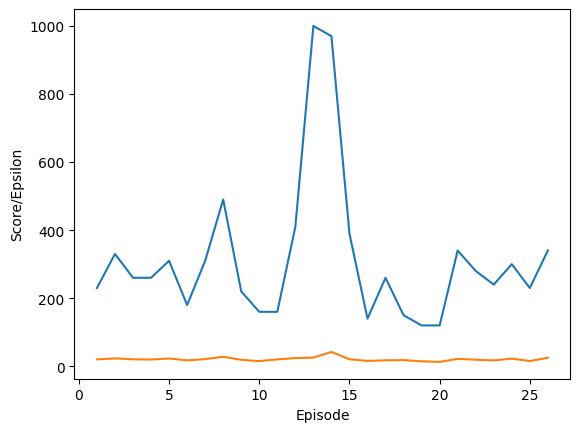

In [17]:
filename = 'AtariDK_Agent1'


loaded_scores = load_array("datasets/pacman_screenshots/100_game/data/games_scores.txt")
loaded_eps_history = load_array("datasets/pacman_screenshots/100_game/data/games_epsilon.txt")

x = [i + 1 for i in range(len(loaded_scores))]

plt.plot(x, loaded_scores)
plt.plot(x, loaded_eps_history)
plt.xlabel("Episode")
plt.ylabel("Score/Epsilon")

# plotLearning(x, scores, eps_history, filename)


In [15]:
"""
Valores del Agente para la primera iteracion
gamma=0.99,
epsilon=1.0,
alpha=0.0005,
input_dims=(210, 160, 3),
n_actions=len(actions_map.keys()),
mem_size=1000,
batch_size=64,
epsilon_end=0.01
"""


